<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_7_BankNote_Authentication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

spark = (
    SparkSession.builder
    .appName("BankNoteAuthentication")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [2]:
DATA_PATH = "/content/BankNote_Authentication.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.printSchema()
df.show(5)

Total Rows: 1372
Total Columns: 5
root
 |-- variance: double (nullable = true)
 |-- skewness: double (nullable = true)
 |-- curtosis: double (nullable = true)
 |-- entropy: double (nullable = true)
 |-- class: integer (nullable = true)

+--------+--------+--------+--------+-----+
|variance|skewness|curtosis| entropy|class|
+--------+--------+--------+--------+-----+
|  3.6216|  8.6661| -2.8073|-0.44699|    0|
|  4.5459|  8.1674| -2.4586| -1.4621|    0|
|   3.866| -2.6383|  1.9242| 0.10645|    0|
|  3.4566|  9.5228| -4.0112| -3.5944|    0|
| 0.32924| -4.4552|  4.5718| -0.9888|    0|
+--------+--------+--------+--------+-----+
only showing top 5 rows


In [4]:
print("Statistical Summary:")
df.describe().show()

print("Missing Values:")

df.select([
    F.sum(
        F.when(F.col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in df.columns
]).show()

print("Class Distribution:")
df.groupBy("class").count().show()

df_clean = df.dropna()

print("Rows after cleaning:", df_clean.count())

Statistical Summary:
+-------+------------------+------------------+------------------+------------------+------------------+
|summary|          variance|          skewness|          curtosis|           entropy|             class|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|              1372|              1372|              1372|              1372|              1372|
|   mean|0.4337352570699707|1.9223531206393603|1.3976271172667651|-1.191656520043731|0.4446064139941691|
| stddev|2.8427625862785577| 5.869046743695513| 4.310030090106595| 2.101013137359609|0.4971032701256608|
|    min|           -7.0421|          -13.7731|           -5.2861|           -8.5482|                 0|
|    max|            6.8248|           12.9516|           17.9274|            2.4495|                 1|
+-------+------------------+------------------+------------------+------------------+------------------+

Missing Values:
+--------+-------

In [5]:
# Get all columns except target column
feature_columns = [
    col for col in df_clean.columns
    if col != "class"
]

print("Feature Columns:", feature_columns)

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(df_clean)

data.select(
    "features",
    "class"
).show(5, truncate=False)

Feature Columns: ['variance', 'skewness', 'curtosis', 'entropy']
+--------------------------------+-----+
|features                        |class|
+--------------------------------+-----+
|[3.6216,8.6661,-2.8073,-0.44699]|0    |
|[4.5459,8.1674,-2.4586,-1.4621] |0    |
|[3.866,-2.6383,1.9242,0.10645]  |0    |
|[3.4566,9.5228,-4.0112,-3.5944] |0    |
|[0.32924,-4.4552,4.5718,-0.9888]|0    |
+--------------------------------+-----+
only showing top 5 rows


In [6]:
train_data, test_data = data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())


# Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="class"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)


# Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="class",
    numTrees=50,
    seed=42
)

rf_model = rf.fit(train_data)

rf_predictions = rf_model.transform(test_data)


# Evaluation
evaluator = MulticlassClassificationEvaluator(
    labelCol="class",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy, 4))
print("Random Forest Accuracy:", round(rf_accuracy, 4))

Training Records: 1137
Testing Records: 235
Logistic Regression Accuracy: 0.983
Random Forest Accuracy: 0.9745


+-------------------+------------------+
|              Model|          Accuracy|
+-------------------+------------------+
|Logistic Regression|0.9829787234042553|
|      Random Forest|0.9744680851063829|
+-------------------+------------------+



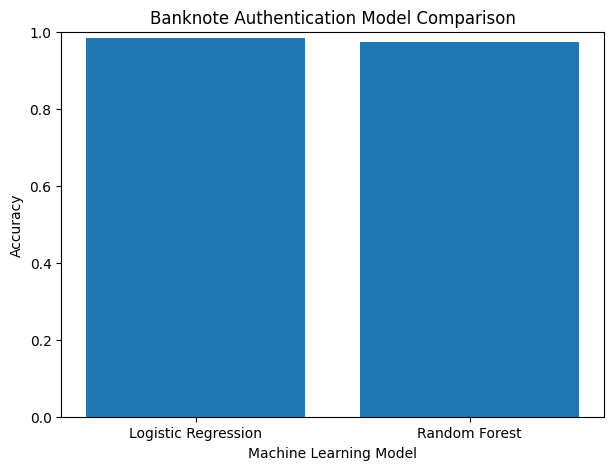


BANKNOTE AUTHENTICATION USING PYSPARK

PROJECT COMPLETED SUCCESSFULLY

DATA PROCESSING:
• Spark DataFrames
• Statistical analysis
• Missing value checking
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Train/Test Split
• Accuracy comparison

CONCLUSION:
The BankNote Authentication dataset was processed
using PySpark to classify banknotes based on their
numerical characteristics.

Two machine learning models were trained and compared
to identify the most effective approach for banknote
authentication.

PROJECT COMPLETE



In [7]:
results = [
    ("Logistic Regression", float(lr_accuracy)),
    ("Random Forest", float(rf_accuracy))
]

results_df = spark.createDataFrame(
    results,
    ["Model", "Accuracy"]
)

results_df.show()


# Visualisation
results_pd = results_df.toPandas()

plt.figure(figsize=(7, 5))

plt.bar(
    results_pd["Model"],
    results_pd["Accuracy"]
)

plt.title("Banknote Authentication Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.show()


print("""
====================================================
BANKNOTE AUTHENTICATION USING PYSPARK
====================================================

PROJECT COMPLETED SUCCESSFULLY

DATA PROCESSING:
• Spark DataFrames
• Statistical analysis
• Missing value checking
• Feature vector creation

MACHINE LEARNING MODELS:
• Logistic Regression
• Random Forest Classifier

MODEL EVALUATION:
• Train/Test Split
• Accuracy comparison

CONCLUSION:
The BankNote Authentication dataset was processed
using PySpark to classify banknotes based on their
numerical characteristics.

Two machine learning models were trained and compared
to identify the most effective approach for banknote
authentication.

====================================================
PROJECT COMPLETE
====================================================
""")